# 1) Chargement des données

Allez, cadeau 😘:

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_PATH = "C:/Users/ALVAREZA/Desktop/oc/billets.csv"

if not os.path.exists(DATA_PATH):
    print(f"❌ Attention : le fichier '{DATA_PATH}' n'existe pas.")

try:
    df = pd.read_csv(DATA_PATH, sep=";")
    print("✅ Données chargées :", df.shape)
    display(df.head())
except Exception as e:
    print("❌ Erreur lors du chargement :", e)
    print("⚠️ Tu as bien lu le code avant de l'executer ? 😏")


✅ Données chargées : (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


# 2) Analyse exploratoire (EDA)


Là, c'est vous les pro 💪, je vous fais entièrement confiance 😉 !

Pssst (indice) : trouvez des variables corrélées à votre objectif, ça marche mieux 😉.

In [2]:
df.isna().sum()

is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

In [3]:
df[df.isna().any(axis=1)]

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
72,True,171.94,103.89,103.45,NaN,3.25,112.79
99,True,171.93,104.07,104.18,NaN,3.14,113.08
151,True,172.07,103.80,104.38,NaN,3.02,112.93
197,True,171.45,103.66,103.80,NaN,3.62,113.27
241,True,171.83,104.14,104.06,NaN,3.02,112.36
251,True,171.80,103.26,102.82,NaN,2.95,113.22
284,True,171.92,103.83,103.76,NaN,3.23,113.29
334,True,171.85,103.70,103.96,NaN,3.00,113.36
410,True,172.56,103.72,103.51,NaN,3.12,112.95
413,True,172.30,103.66,103.50,NaN,3.16,112.95


In [4]:
df=df.dropna()

In [5]:
df.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1463.000000,1463.000000,1463.000000,1463.000000,1463.000000,1463.000000
mean,171.959193,104.031333,103.921476,4.485967,3.153083,112.674757
std,0.305457,0.299605,0.324181,0.663813,0.231466,0.873222
min,171.040000,103.140000,102.910000,2.980000,2.270000,109.490000
25%,171.750000,103.825000,103.710000,4.015000,2.990000,112.020000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.960000
75%,172.170000,104.230000,104.150000,4.870000,3.315000,113.340000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.320000


In [6]:
df_genuine=df[df['is_genuine']==True]
df_fake=df[df['is_genuine']==False]

In [7]:
df_genuine_desc = df_genuine.describe()
df_genuine_desc

,diagonal,height_left,height_right,margin_low,margin_up,length
count,971.000000,971.000000,971.000000,971.000000,971.000000,971.000000
mean,171.988476,103.951679,103.809094,4.116097,3.052544,113.203059
std,0.301402,0.301518,0.288862,0.319124,0.185425,0.356123
min,171.040000,103.140000,102.910000,2.980000,2.270000,111.760000
25%,171.790000,103.745000,103.610000,3.905000,2.925000,112.960000
50%,171.990000,103.950000,103.810000,4.110000,3.050000,113.200000
75%,172.200000,104.140000,104.000000,4.340000,3.180000,113.460000
max,172.920000,104.860000,104.950000,5.040000,3.740000,114.320000


In [8]:
df_fake_desc = df_fake.describe()
df_fake_desc

,diagonal,height_left,height_right,margin_low,margin_up,length
count,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000
mean,171.901402,104.188537,104.143272,5.215935,3.351504,111.632114
std,0.305473,0.224418,0.271683,0.553531,0.179343,0.615343
min,171.040000,103.510000,103.430000,3.820000,2.920000,109.490000
25%,171.697500,104.040000,103.950000,4.840000,3.227500,111.200000
50%,171.910000,104.180000,104.160000,5.190000,3.350000,111.630000
75%,172.092500,104.330000,104.320000,5.592500,3.472500,112.030000
max,173.010000,104.880000,104.950000,6.900000,3.910000,113.850000


In [9]:
(df_genuine_desc-df_fake_desc)/df_genuine_desc

,diagonal,height_left,height_right,margin_low,margin_up,length
count,0.493306,0.493306,0.493306,0.493306,0.493306,0.493306
mean,0.000506,-0.002279,-0.003219,-0.267204,-0.097938,0.013877
std,-0.013508,0.255706,0.059471,-0.734534,0.032798,-0.727896
min,0.000000,-0.003587,-0.005053,-0.281879,-0.286344,0.020311
25%,0.000538,-0.002844,-0.003282,-0.239437,-0.103419,0.015581
50%,0.000465,-0.002213,-0.003372,-0.262774,-0.098361,0.013869
75%,0.000624,-0.001824,-0.003077,-0.288594,-0.091981,0.012604
max,-0.000520,-0.000191,0.000000,-0.369048,-0.045455,0.004111


In [10]:
df_genuine_desc-df_fake_desc

,diagonal,height_left,height_right,margin_low,margin_up,length
count,479.000000,479.000000,479.000000,479.000000,479.000000,479.000000
mean,0.087073,-0.236858,-0.334179,-1.099838,-0.298960,1.570945
std,-0.004071,0.077100,0.017179,-0.234407,0.006082,-0.259220
min,0.000000,-0.370000,-0.520000,-0.840000,-0.650000,2.270000
25%,0.092500,-0.295000,-0.340000,-0.935000,-0.302500,1.760000
50%,0.080000,-0.230000,-0.350000,-1.080000,-0.300000,1.570000
75%,0.107500,-0.190000,-0.320000,-1.252500,-0.292500,1.430000
max,-0.090000,-0.020000,0.000000,-1.860000,-0.170000,0.470000


<Axes: ylabel='count'>

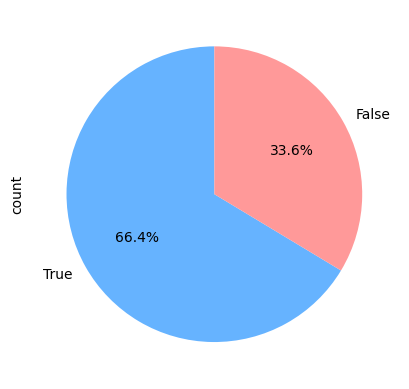

In [11]:
counts = df['is_genuine'].value_counts()
counts.plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], labels=['True', 'False'], startangle=90)

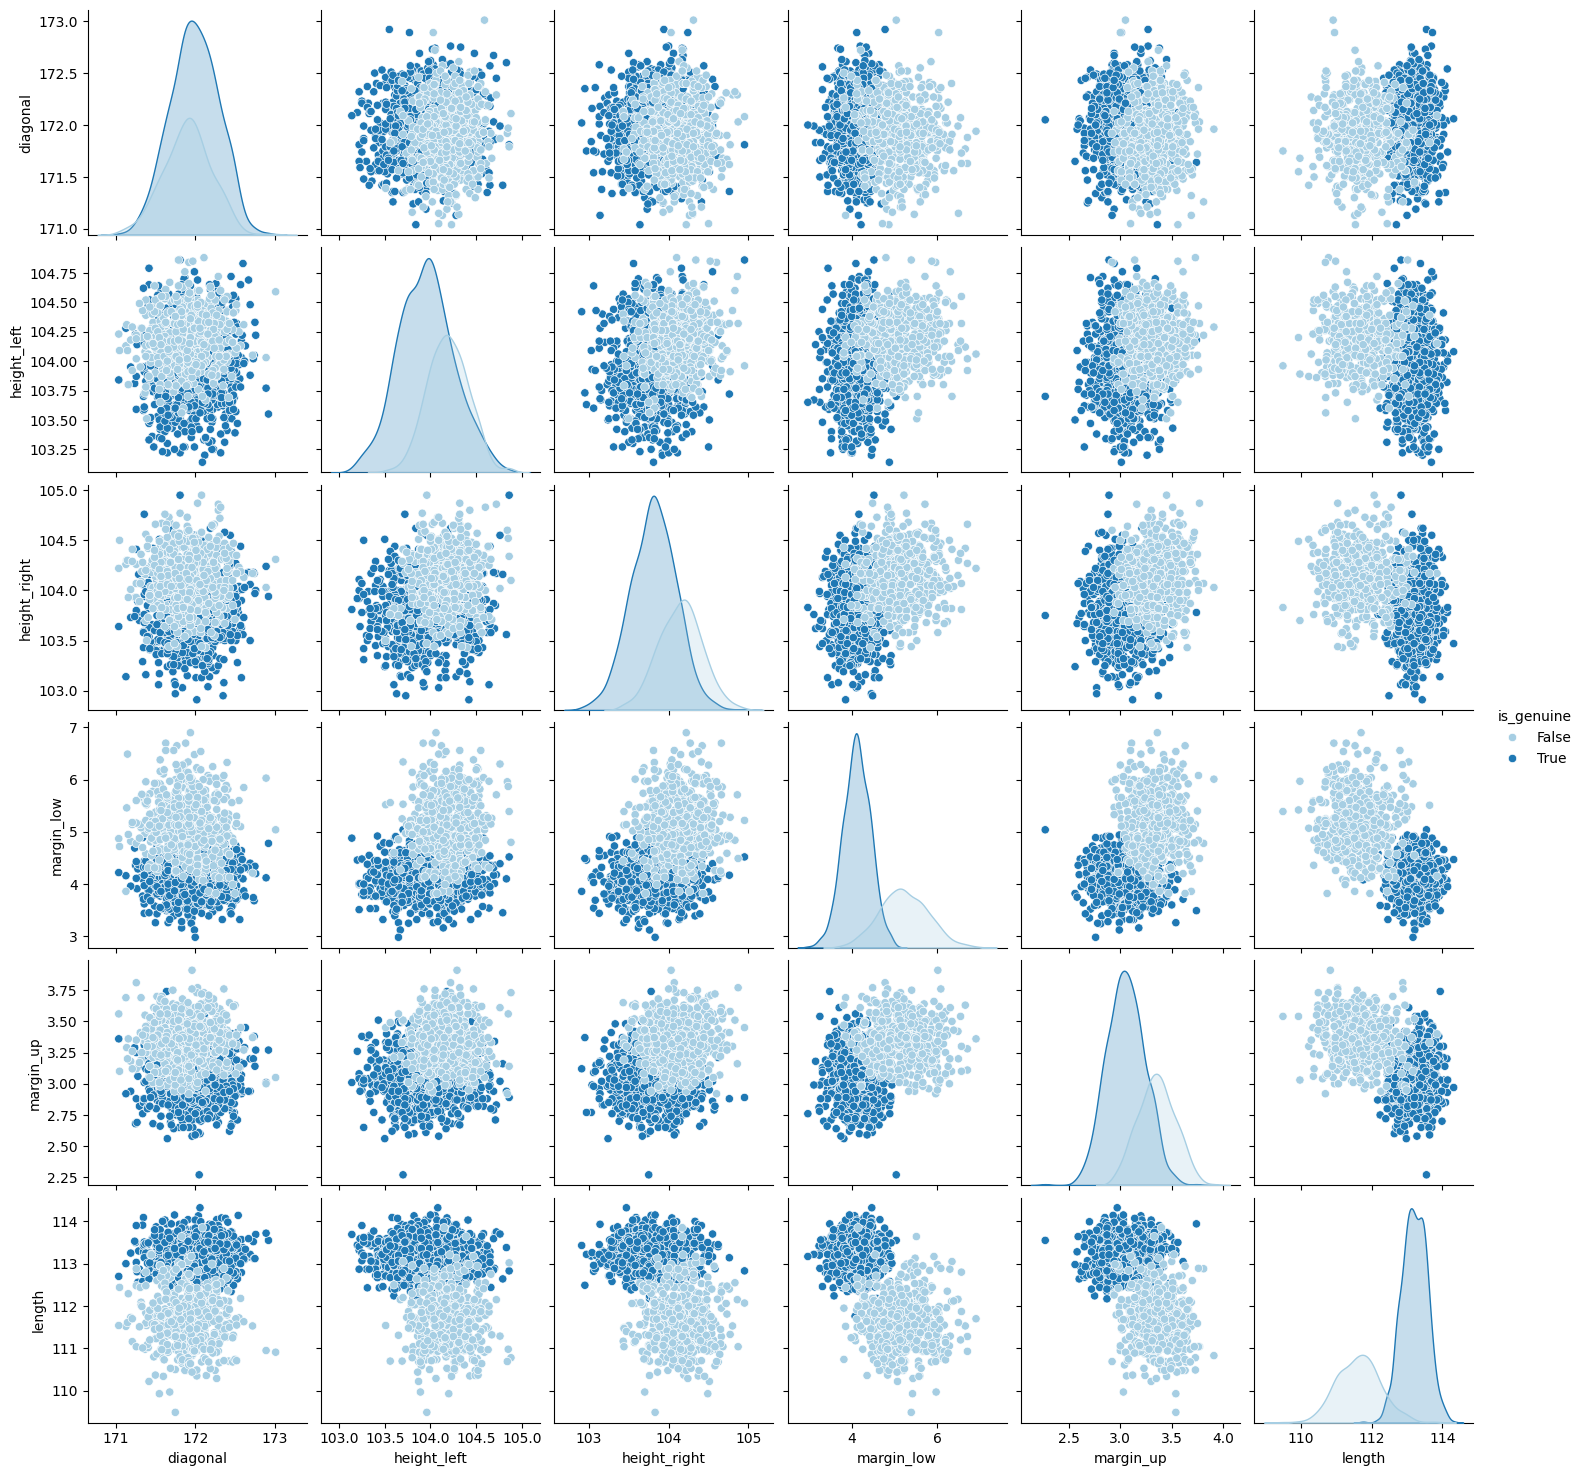

In [12]:
sns.pairplot(df,hue='is_genuine',palette='Paired')

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=6)
pca.fit(df)

,n_components,6
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [14]:
print(pca.explained_variance_ratio_)

[0.71241023 0.10421836 0.05490478 0.0487111  0.04127971 0.02492762]


In [15]:
print(pca.singular_values_)

[42.91519626 16.41414046 11.91382224 11.22173509 10.33033367  8.0276134 ]


# 3) Prétraitement

Le but est de transformer tes données brutes (les valeurs mesurées des billets) en données que les algorithmes de Machine Learning peuvent comprendre efficacement.


D'abord, il faut séparer les variables explicatives et la cible :

X = les mesures du billet (longueur, hauteur, diagonales…)

y = l’étiquette (vrai ou faux)

➡️ Pourquoi ?
Parce que le modèle doit apprendre à prédire y en fonction de X.

In [16]:
X = df.drop(columns=['is_genuine']) # Toutes les colonnes sauf la cible
y = df["is_genuine"] # La colonne cible

In [17]:
X

,diagonal,height_left,height_right,margin_low,margin_up,length
0,171.81,104.86,104.95,4.52,2.89,112.83
1,171.46,103.36,103.66,3.77,2.99,113.09
2,172.69,104.48,103.50,4.40,2.94,113.16
3,171.36,103.91,103.94,3.62,3.01,113.51
4,171.73,104.28,103.46,4.04,3.48,112.54
...,...,...,...,...,...,...
1495,171.75,104.38,104.17,4.42,3.09,111.28
1496,172.19,104.63,104.44,5.27,3.37,110.97
1497,171.80,104.01,104.12,5.51,3.36,111.95
1498,172.06,104.28,104.06,5.17,3.46,112.25


In [18]:
y

0        True
1        True
2        True
3        True
4        True
        ...  
1495    False
1496    False
1497    False
1498    False
1499    False
Name: is_genuine, Length: 1463, dtype: bool

Autre point important : on entraîne toujours le modèle sur un morceau des données, et on teste sur un autre qu’il n’a jamais vu.

➡️ Pourquoi ?
Pour éviter le sur-apprentissage (le modèle apprend par cœur sans savoir généraliser).

In [19]:
from sklearn.preprocessing import StandardScaler


scaler_pca = StandardScaler()
scaler_pca.fit(X)
X_pca = pd.DataFrame(scaler_pca.transform(X),columns=list(df.columns[1:]))


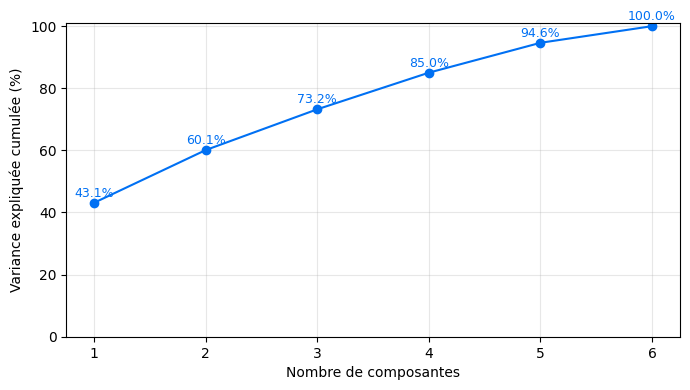

Nombre de composantes pour expliquer 95% de la variance : 6


In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 2. ACP sans réduction pour voir la variance expliquée
pca = PCA()
X_pca = pca.fit_transform(X_pca)
explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()

plt.figure(figsize=(7,4))
x = range(1, len(explained)+1)
plt.plot(x, cumulative*100, marker='o', color="#0070f3")
plt.ylim(0, 101)
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée (%)')
plt.grid(alpha=0.3)

# Afficher la valeur (%) au-dessus de chaque point
for i, val in enumerate(cumulative):
    plt.text(x[i], cumulative[i]*100 + 2, f"{cumulative[i]*100:.1f}%", ha='center', fontsize=9, color="#0070f3")

plt.tight_layout()
plt.show()


# 4. Choix du nombre de composantes (ex: pour 95% de variance)
n_components = (cumulative < 0.95).sum() + 1
print(f"Nombre de composantes pour expliquer 95% de la variance : {n_components}")

# 5. Tu peux transformer tes données sur ce sous-espace :
pca = PCA(n_components=n_components)
X_reduced = pca.fit_transform(X_pca)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y)

Enfin, on met toutes les variables sur la même échelle (moyenne = 0, écart-type = 1).

➡️ Pourquoi ?
Parce que certains modèles, comme le KNN ou la Régression Logistique, sont sensibles aux différences d’échelle.
Sans standardisation, la variable la plus grande numériquement prend trop d’importance.

In [44]:
scaler = StandardScaler()
# Use scaler on X_train and X_test
scaler.fit(X_train)
print("Moyennes et écart-types")
print(scaler.mean_)
print(scaler.scale_)
X_train_transformed = pd.DataFrame(scaler.transform(X_train),columns=list(df.columns[1:]))
X_test_transformed = pd.DataFrame(scaler.transform(X_test),columns=list(df.columns[1:]))

Moyennes et écart-types
[171.96076923 104.03392308 103.9204188    4.48967521   3.1528547
 112.66583761]
[0.3050466  0.30193464 0.32535279 0.65526303 0.22898301 0.88477648]


In [23]:
X_train_transformed

,diagonal,height_left,height_right,margin_low,margin_up,length
0,-0.940366,0.277142,0.187172,1.788085,0.124531,-1.295443
1,1.273506,0.343765,0.431651,-0.565289,-0.605265,1.259254
2,-0.973409,-2.021363,-1.157460,-0.160569,1.541196,0.594804
3,-0.808195,-0.155910,-1.371379,0.004318,-0.476478,0.445875
4,-0.907323,-0.489027,-0.668503,2.222784,-0.519407,-3.105498
...,...,...,...,...,...,...
1165,0.216134,0.477012,0.737250,-0.775144,0.339178,1.098869
1166,0.017877,-1.188572,-0.240665,-0.040651,-0.347690,0.067826
1167,-0.180380,-0.322468,-1.646418,-1.224833,-1.206275,0.686452
1168,-0.048209,1.009998,-0.637943,-1.224833,0.081602,-0.000911


In [24]:
X_test_transformed

,diagonal,height_left,height_right,margin_low,margin_up,length
0,-3.022066,-0.655585,-0.851862,-0.400403,0.897258,0.022001
1,-1.006452,-0.122598,1.867964,1.803074,1.111904,-1.822421
2,0.711777,0.077272,-1.676978,-0.250506,0.682611,1.121781
3,-1.006452,0.843440,-0.332345,-0.340444,-0.433549,1.030133
4,1.174377,-0.355780,-1.829777,0.364069,-1.292133,0.629172
...,...,...,...,...,...,...
288,1.703063,0.776817,0.553891,0.588914,0.768470,-2.292119
289,0.348306,0.810128,0.431651,1.023613,1.326550,-0.493520
290,-1.138623,-0.588962,0.431651,-0.265496,-0.218902,-0.046735
291,0.843949,-0.788832,-2.104815,-1.179864,-0.734053,0.308402


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

for n_components in [5, 6]:
    print(f"\n--- {n_components} composantes principales ---")
    pipeline = make_pipeline(
        StandardScaler(),
        PCA(n_components=n_components),
        LogisticRegression(max_iter=100)
    )
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))



--- 5 composantes principales ---
Accuracy: 0.9897610921501706
              precision    recall  f1-score   support

       False       1.00      0.97      0.98        99
        True       0.98      1.00      0.99       194

    accuracy                           0.99       293
   macro avg       0.99      0.98      0.99       293
weighted avg       0.99      0.99      0.99       293


--- 6 composantes principales ---
Accuracy: 0.9897610921501706
              precision    recall  f1-score   support

       False       1.00      0.97      0.98        99
        True       0.98      1.00      0.99       194

    accuracy                           0.99       293
   macro avg       0.99      0.98      0.99       293
weighted avg       0.99      0.99      0.99       293



# 4) Modélisation

Dans tous domaines, vous ne pouvez pas progresser si vous ne comprenez pas comment vos outils fonctionnent.

Avant d'utiliser les modèles mathématiques qui suivent, je vous recommande donc de visionner les vidéos suivantes:
* [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)
* [StatQuest: K-nearest neighbors, Clearly Explained](https://youtu.be/HVXime0nQeI)
* [StatQuest: Random Forests Part 1 - Building, Using and Evaluating](https://youtu.be/J4Wdy0Wc_xQ)
* [StatQuest: Random Forests Part 2: Missing data and clustering](https://www.youtube.com/watch?v=sQ870aTKqiM)
* [StatQuest: K-means clustering](https://youtu.be/4b5d3muPQmA)

Peut-être ajouter:
* [StatQuest: playlist XGBoost](https://www.youtube.com/watch?v=OtD8wVaFm6E&list=PLblh5JKOoLULU0irPgs1SnKO6wqVjKUsQ)
* [StatQuest: playlist Gradient Boost](https://www.youtube.com/watch?v=3CC4N4z3GJc&list=PLblh5JKOoLUJjeXUvUE0maghNuY2_5fY6)
* [StatQuest: playlist Neural Networks](https://www.youtube.com/watch?v=zxagGtF9MeU&list=PLblh5JKOoLUIxGDQs4LFFD--41Vzf-ME1)

In [49]:
from sklearn.linear_model import LogisticRegression

# 1) Initialisez une régression logistic.
    # Quels sont les paramètres ajustables de ce modèle ?
    # Bien que vous puissez laisser la majorité d'entre eux par défaut,
    # il vaut mieux, à minima, ajuster `max_iter` pour plafonner le temps de calcul.
log = LogisticRegression(max_iter=100)

# 2) Entrainez le modèle avec vos données X_train et y_train
log.fit(X_train_transformed,y_train)

# 3) Utiliser la régression logistique pour déterminer les vrais / faux billets de X_test.
y_pred_log = pd.DataFrame(log.predict_proba(X_test_transformed),columns=['pred','pred'])


In [50]:
y_pred_log

,pred,pred
0,0.000400,0.999600
1,0.000004,0.999996
2,0.000232,0.999768
3,0.999889,0.000111
4,0.999941,0.000059
...,...,...
288,0.001232,0.998768
289,0.993908,0.006092
290,0.000320,0.999680
291,0.000306,0.999694


In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Précision
accuracy = accuracy_score(y_test, y_pred_log) 
print(f"Précision: {accuracy:.2f}")
print("")

# Matrice de confusion
print("Matrice de confusion :")
print(confusion_matrix(y_test,y_pred_log))
print("")

# Rapport complet
print("Rapport complet :")
print(classification_report(y_test,y_pred_log))

Précision: 0.66

Matrice de confusion :
[[  0  99]
 [  0 194]]

Rapport complet :
              precision    recall  f1-score   support

       False       0.00      0.00      0.00        99
        True       0.66      1.00      0.80       194

    accuracy                           0.66       293
   macro avg       0.33      0.50      0.40       293
weighted avg       0.44      0.66      0.53       293



c:\Users\ALVAREZA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ALVAREZA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ALVAREZA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [28]:
from sklearn.neighbors import KNeighborsClassifier

# Répéter les même étapes que pour la régression logistique mais avec le KNN.
knn = KNeighborsClassifier(n_neighbors=3,weights='distance')
knn.fit(X_train_transformed,y_train)
y_pred_knn = pd.DataFrame(knn.predict(X_test_transformed),columns=['pred'])


In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Précision
accuracy = accuracy_score(y_test, y_pred_knn) 
print(f"Précision: {accuracy:.2f}")
print("")

# Matrice de confusion
print("Matrice de confusion :")
print(confusion_matrix(y_test,y_pred_knn))
print("")

# Rapport complet
print("Rapport complet :")
print(classification_report(y_test,y_pred_knn))

Précision: 0.57

Matrice de confusion :
[[ 23  76]
 [ 50 144]]

Rapport complet :
              precision    recall  f1-score   support

       False       0.32      0.23      0.27        99
        True       0.65      0.74      0.70       194

    accuracy                           0.57       293
   macro avg       0.48      0.49      0.48       293
weighted avg       0.54      0.57      0.55       293



In [30]:
from sklearn.ensemble import RandomForestClassifier

# hum... devinez ce qu'il faut faire 😁.
rf = RandomForestClassifier()
rf.fit(X_train_transformed,y_train)
y_pred_rf = pd.DataFrame(rf.predict(X_test_transformed),columns=['pred'])



In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Précision
accuracy = accuracy_score(y_test, y_pred_knn) 
print(f"Précision: {accuracy:.2f}")
print("")

# Matrice de confusion
print("Matrice de confusion :")
print(confusion_matrix(y_test,y_pred_knn))
print("")

# Rapport complet
print("Rapport complet :")
print(classification_report(y_test,y_pred_knn))

Précision: 0.57

Matrice de confusion :
[[ 23  76]
 [ 50 144]]

Rapport complet :
              precision    recall  f1-score   support

       False       0.32      0.23      0.27        99
        True       0.65      0.74      0.70       194

    accuracy                           0.57       293
   macro avg       0.48      0.49      0.48       293
weighted avg       0.54      0.57      0.55       293



In [32]:
from sklearn.cluster import KMeans

# Attention ! Cet algo est très différents de ceux utilisés précédemment.
# Peux-tu voir les différences ?
# Du coup, cet algo est-il utile (voir pertinent) pour cette étude ?

# Pas utile car il ne sait pas distinguer vrai/faux, il fait juste des groupes sans label
# On pourrait faire un KMeans avec 2 groupes, mais il faudrait à chaque fois deviner quel groupe correpond aux vrais billets, et quel groupe correspond aux faux billets
# Et s'il y a plusieurs types de faux billets ça ne marcherait plus, par exemple si on a des faux billets petits, des faux billets gros, et les vrais billets entre les deux
# alors ça ne donnerait pas un bon résultat
km = KMeans(n_clusters=2)
km.fit(X_train_transformed)
y_pred_km = pd.DataFrame(km.predict(X_test_transformed),columns=['pred'])


In [33]:
y_pred_km

,pred
0,0
1,1
2,0
3,0
4,0
...,...
288,1
289,1
290,0
291,0


# Sélection du meilleur modèle

Mais alors, quel est le meilleur modèle pour résoudre ce problème ?

Pour répondre à cette question, il vous faut bien comprendre l'intérêt de chacune des métriques d'évaluation qui existent pour ce type de problème.

Vous me voyez venir... 😎 : StatQuest !!! 🤩
* [Machine Learning Fundamentals: Sensitivity and Specificity
](https://youtu.be/vP06aMoz4v8)
* [Machine Learning Fundamentals: The Confusion Matrix](https://youtu.be/Kdsp6soqA7o)
* [ROC and AUC, Clearly Explained!](https://youtu.be/4jRBRDbJemM)

Vous avez aussi des petits modules sympathiques sur Sklearn qui vous machent grandement le travail:
* [Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
* [Confusion Matrix Display](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
* [Classification Report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

A vous de jouer ! 🚀

In [34]:
accuracies = { 'logistic_regression': [], 'knn': [], 'random_forest': [] }
for i in range(100):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.5,stratify=y)
    X_train_transformed = pd.DataFrame(scaler.transform(X_train),columns=list(df.columns[1:]))
    X_test_transformed = pd.DataFrame(scaler.transform(X_test),columns=list(df.columns[1:]))
    log = LogisticRegression(max_iter=100)
    log.fit(X_train_transformed,y_train)
    y_pred_log = pd.DataFrame(log.predict(X_test_transformed),columns=['pred'])
    knn = KNeighborsClassifier(n_neighbors=3,weights='distance')
    knn.fit(X_train_transformed,y_train)
    y_pred_knn = pd.DataFrame(knn.predict(X_test_transformed),columns=['pred'])
    rf = RandomForestClassifier()
    rf.fit(X_train_transformed,y_train)
    y_pred_rf = pd.DataFrame(rf.predict(X_test_transformed),columns=['pred'])
    accuracy_log = accuracy_score(y_test, y_pred_log)
    accuracy_knn = accuracy_score(y_test, y_pred_knn)
    accuracy_rf = accuracy_score(y_test, y_pred_rf)
    accuracies['logistic_regression'].append(accuracy_log) 
    accuracies['knn'].append(accuracy_knn) 
    accuracies['random_forest'].append(accuracy_rf)
accuracies = pd.DataFrame(accuracies)

In [35]:
accuracies.sum()

logistic_regression    99.072404
knn                    98.881148
random_forest          99.061475
dtype: float64

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# C'est là qu'on voit qui sont les bons 😉!

# Sauvegarde du meilleur modèle

**_ATTENTION_** :
```
Sauvegarder un modèle implique de sauvegarder aussi les étapes de préprocessing des données.
Dans votre cas, vous devez donc inclure, à minima, votre StandardScaler.
```
Voir [`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) pour plus d'infos.

In [37]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

import joblib

# Utilisez make_pipeline pour inclure toutes les étapes nécessaires
# à la prédiction de si un billet est vrai ou faux.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
pipeline = make_pipeline(StandardScaler(),LogisticRegression(max_iter=100))
pipeline.fit(X_train,y_train)
pipeline.predict(X_test)

# Sauvegardez votre modèle à l'aide de la librairie joblib.
joblib.dump(pipeline,"modele_billets.joblib")

['modele_billets.joblib']

In [38]:
loaded_pipeline = joblib.load('modele_billets.joblib')


In [39]:
%gui qt

In [40]:
from pathlib import Path
import pandas as pd
import joblib
from PyQt6.QtWidgets import QApplication, QWidget, QVBoxLayout, QHBoxLayout, QLabel, QFileDialog, QLineEdit, QFrame, QSizePolicy
from PyQt6.QtGui import QFont, QColor, QPainter, QPen
from PyQt6.QtCore import Qt, pyqtSignal, QTimer, QEvent, QRectF, QSettings, pyqtProperty, QEasingCurve, QPropertyAnimation

REQUIRED_COLUMNS = ['diagonal','height_left','height_right','margin_low','margin_up','length']
lighten = lambda hex_color, f=140: QColor(hex_color).lighter(f)

# Switch animé
class Switch(QWidget):
    toggled = pyqtSignal(bool)
    def __init__(self, checked=False, parent=None):
        super().__init__(parent); self._checked=checked; self._offset=1.0 if checked else 0.0
        self.setFixedSize(54,28); self.setCursor(Qt.CursorShape.PointingHandCursor)
        self.anim = QPropertyAnimation(self, b"offset", duration=160, easingCurve=QEasingCurve.Type.InOutCubic)
    def mousePressEvent(self, _): self.setChecked(not self._checked); self.toggled.emit(self._checked)
    def isChecked(self): return self._checked
    def setChecked(self, v:bool): self._checked=v; self.anim.stop(); self.anim.setStartValue(self._offset); self.anim.setEndValue(1.0 if v else 0.0); self.anim.start()
    def getOffset(self): return self._offset
    def setOffset(self, x): self._offset=float(x); self.update()
    offset = pyqtProperty(float, fget=getOffset, fset=setOffset)
    def paintEvent(self, _):
        p=QPainter(self); p.setRenderHint(QPainter.RenderHint.Antialiasing, True)
        track_on, track_off = QColor("#e5e7eb"), QColor("#4b5563")
        border_on, border_off = QColor("#cbd5e1"), QColor("#1f2937")
        bg = track_on if self._checked else track_off; bd = border_on if self._checked else border_off
        r = QRectF(self.rect()).adjusted(0.75,0.75,-0.75,-0.75)
        p.setBrush(bg); p.setPen(QPen(bd,1.5)); p.drawRoundedRect(r,14,14)
        m=3; d=self.height()-2*m; x=m + self._offset*(self.width()-2*m-d)
        p.setBrush(QColor("#ffffff")); p.setPen(Qt.PenStyle.NoPen); p.drawEllipse(QRectF(x,m,d,d))

# Barre de statut sensible au thème
class StatusBar(QFrame):
    def __init__(self, parent=None):
        super().__init__(parent)
        self.setMinimumHeight(44); self.setSizePolicy(QSizePolicy.Policy.Expanding, QSizePolicy.Policy.Fixed)
        self.label = QLabel("PRÊT", self); self.label.setAlignment(Qt.AlignmentFlag.AlignCenter)
        f=QFont("Segoe UI",12); f.setWeight(QFont.Weight.Bold); self.label.setFont(f)
        self.theme="dark"; self.accent="idle"
        self.fill=QColor("#2f3b4a"); self.border=lighten("#2f3b4a")
        self.label.setStyleSheet("color:#fff;background:transparent;")
    def setTheme(self, theme:str): self.theme=theme; self.setAccent(self.accent)
    def setAccent(self, key:str):
        self.accent=key
        palettes = {
            "dark":   {"idle":"#2f3b4a","info":"#0b76b0","success":"#1a9c4a","warn":"#b07c10","error":"#b93a3a"},
            "light":  {"idle":"#cbd5e1","info":"#38bdf8","success":"#34d399","warn":"#facc15","error":"#f87171"},
        }
        base = palettes.get(self.theme, palettes["dark"]).get(key, "#0b76b0")
        self.fill=QColor(base); self.border=lighten(base); self.update()
    def setText(self, text:str): self.label.setText(text.upper()); self.update()
    def resizeEvent(self,e): self.label.setGeometry(self.rect()); super().resizeEvent(e)
    def paintEvent(self,_):
        p=QPainter(self); p.setRenderHint(QPainter.RenderHint.Antialiasing, True)
        r=QRectF(self.rect()).adjusted(0.75,0.75,-0.75,-0.75)
        p.setBrush(self.fill); p.setPen(QPen(self.border,1.5)); p.drawRoundedRect(r,12,12)

class DropArea(QFrame):
    fileSelected = pyqtSignal(str)
    def __init__(self, parent=None):
        super().__init__(parent); self.setObjectName("DropArea"); self.setAcceptDrops(True)
        self.setMinimumHeight(170); self.setSizePolicy(QSizePolicy.Policy.Expanding, QSizePolicy.Policy.Expanding)
        self.label = QLabel("Déposez votre CSV ici ou cliquez pour parcourir", self)
        self.label.setAlignment(Qt.AlignmentFlag.AlignCenter)
        f=QFont("Segoe UI",12); f.setWeight(QFont.Weight.DemiBold); self.label.setFont(f)
        lay=QVBoxLayout(self); lay.setContentsMargins(22,22,22,22); lay.addWidget(self.label)
        self.setTheme("dark")
    def setTheme(self, theme):
        if theme=="light":
            self._base="QFrame#DropArea{background:qlineargradient(x1:0,y1:0,x2:1,y2:1,stop:0 #ffffff,stop:1 #f3f4f6);border:1px solid #d1d5db;border-radius:14px;color:#111827;}"
            self._active="QFrame#DropArea{background:qlineargradient(x1:0,y1:0,x2:1,y2:1,stop:0 #f8fafc,stop:1 #eef2f7);border:1px solid #0ea5e9;border-radius:14px;color:#111827;}"
            self.label.setStyleSheet("color:#111827;")
        else:
            self._base="QFrame#DropArea{background:qlineargradient(x1:0,y1:0,x2:1,y2:1,stop:0 #11151b,stop:1 #0c1117);border:1px solid #1f2937;border-radius:14px;color:#e6edf3;}"
            self._active="QFrame#DropArea{background:qlineargradient(x1:0,y1:0,x2:1,y2:1,stop:0 #101821,stop:1 #0b1720);border:1px solid #0ea5e9;border-radius:14px;color:#e6edf3;}"
            self.label.setStyleSheet("color:#e6edf3;")
        self.setStyleSheet(self._base)
    def setActive(self,a): self.setStyleSheet(self._active if a else self._base)
    def dragEnterEvent(self,e):
        urls=e.mimeData().urls()
        if urls and urls[0].toLocalFile().lower().endswith(".csv"): self.setActive(True); e.acceptProposedAction()
    def dragLeaveEvent(self,_): self.setActive(False)
    def dropEvent(self,e):
        self.setActive(False); urls=e.mimeData().urls()
        if urls: self.fileSelected.emit(urls[0].toLocalFile())
    def mousePressEvent(self,_):
        top=self.parentWidget()
        if top and hasattr(top,"sep_edit"): top.sep_edit.clearFocus()
        start_dir = top.get_last_dir() if top and hasattr(top, "get_last_dir") else ""
        path,_=QFileDialog.getOpenFileName(self,"Ouvrir un fichier CSV",start_dir,"CSV (*.csv)")
        if path:
            if top and hasattr(top, "set_last_dir"):
                top.set_last_dir(path)
            self.fileSelected.emit(path)

class PredictorApp(QWidget):
    def __init__(self):
        super().__init__(); self.setWindowTitle("CSV → Prédiction")
        self.resize(780, 340); self.setMinimumSize(470, 320)
        self.settings = QSettings("SchmidtGroupe","CSVPrediction")
        self.theme = self.settings.value("theme","dark")
        root=QVBoxLayout(self); root.setContentsMargins(16,16,16,16); root.setSpacing(12)
        self.status_bar = StatusBar(self); root.addWidget(self.status_bar)
        row=QHBoxLayout(); row.setSpacing(12)
        row.addWidget(QLabel("Séparateur"))
        self.sep_edit = QLineEdit(self.settings.value("sep", ",")); self.sep_edit.setFixedWidth(64); self.sep_edit.setMaxLength(3)
        self.sep_edit.editingFinished.connect(lambda: self.settings.setValue("sep", self.sep_edit.text() or ","))
        row.addWidget(self.sep_edit); row.addStretch(1)
        row.addWidget(QLabel("Mode clair"))
        self.switch = Switch(checked=(self.theme=="light"))
        self.switch.toggled.connect(lambda on: self.set_theme("light" if on else "dark"))
        row.addWidget(self.switch); root.addLayout(row)
        self.drop = DropArea(self); self.drop.fileSelected.connect(self.handle_file_selected); root.addWidget(self.drop,1)
        try: self.pipeline = joblib.load("modele_billets.joblib"); self._set_status("PRÊT","idle")
        except Exception: self.pipeline=None; self._set_status("PIPELINE INTROUVABLE","error")
        self.set_theme(self.theme); self.installEventFilter(self)
    def set_theme(self, theme):
        self.theme=theme; self.settings.setValue("theme", theme)
        if theme=="light":
            QApplication.instance().setStyleSheet(
                "QWidget{background:#f6f8fb;color:#111827;font-family:'Segoe UI',Arial,sans-serif;font-size:11pt;}"
                "QLabel{color:#111827;} QLineEdit{background:#ffffff;color:#111827;border:1px solid #cbd5e1;border-radius:8px;padding:6px 8px;selection-background-color:#0ea5e9;selection-color:#0b0f14;} QLineEdit:focus{border-color:#0ea5e9;}"
            )
        else:
            QApplication.instance().setStyleSheet(
                "QWidget{background:#0b0f14;color:#e6edf3;font-family:'Segoe UI',Arial,sans-serif;font-size:11pt;}"
                "QLabel{color:#e6edf3;} QLineEdit{background:#121824;color:#e6edf3;border:1px solid #26313d;border-radius:8px;padding:6px 8px;selection-background-color:#0ea5e9;selection-color:#0b0f14;} QLineEdit:focus{border-color:#0ea5e9;}"
            )
        self.drop.setTheme(theme)
        self.status_bar.setTheme(theme)  # adapte la palette de la barre au thème
    def keyPressEvent(self,e):
        if e.key()==Qt.Key.Key_F11: self.showFullScreen() if not self.isFullScreen() else self.showNormal()
        elif e.key()==Qt.Key.Key_Escape and self.isFullScreen(): self.showNormal()
        else: super().keyPressEvent(e)
    def eventFilter(self,obj,e):
        if e.type()==QEvent.Type.MouseButtonPress and self.sep_edit.hasFocus(): self.sep_edit.clearFocus()
        return super().eventFilter(obj, e)
    def handle_file_selected(self, path:str): self.process_csv(path, self.sep_edit.text().strip() or ",")
    def process_csv(self, path:str, sep:str=","):
        if self.pipeline is None: self._set_status("PIPELINE NON CHARGÉ","error"); return
        self._set_status(f"LECTURE: {Path(path).name}","info")
        try:
            df=pd.read_csv(path, sep=sep)
            miss=[c for c in REQUIRED_COLUMNS if c not in df.columns]
            if miss: self._set_status(f"MANQUANT: {', '.join(miss)}","error"); return
            feats=df[REQUIRED_COLUMNS].apply(pd.to_numeric, errors="coerce"); mask=feats.notna().all(axis=1); Xp=feats[mask]
            if Xp.empty: self._set_status("AUCUNE LIGNE VALIDE","warn"); return
            df["prediction"]=pd.NA; df.loc[Xp.index,"prediction"]=self.pipeline.predict(Xp)
            suggested=Path(path).with_name(f"{Path(path).stem}_pred.csv").as_posix()
            save,_=QFileDialog.getSaveFileName(self,"Enregistrer le CSV",suggested,"CSV (*.csv)")
            if save: df.to_csv(save, sep=sep, index=False); self._set_status(f"ENREGISTRÉ: {Path(save).name}","success"); self.drop.setActive(True); QTimer.singleShot(600, lambda: self.drop.setActive(False))
            else: self._set_status("ANNULÉ","warn")
        except Exception as ex: self._set_status(f"ERREUR: {ex}","error")
    def _set_status(self, text, accent): self.status_bar.setText(text); self.status_bar.setAccent(accent)
    def get_last_dir(self): default=str(Path.home()/"Desktop"); return self.settings.value("last_dir",default)
    def set_last_dir(self,filepath): self.settings.setValue("last_dir", str(Path(filepath).parent))

if __name__ == "__main__":
    app = QApplication.instance() or QApplication([])
    w = PredictorApp(); w.show()
